
# Paper A Assets — Q1-Ready Figures and Tables

This notebook regenerates the paper tables and figures for the **proposed model** only, using the corrected final results and the final project log.

**Important source contract**

- The proposed model is the script-aware ensemble formerly referred to as *Model A* in the experiment log.
- Figure and table labels use **Proposed model**, not *Model A*.
- The notebook does **not** read `outputs/precheck/` or `outputs/altmethod/`.
- Values are taken from the final experiment log and official main outputs: `ensemble`, `models_main`, `ablation`, `robustness`, `basepaper`, `baselines`, plus the dataset inventory files.
- It corrects the inconsistent total-count typo by using the internally consistent final benchmark total: **94,323** = class-distribution sum = random split sum = source/script held-out count sum.


In [157]:

# ============================================================
# 0) Imports, paths, and strict source policy
# ============================================================
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

BANNED_PARTS = {"precheck", "altmethod"}
INCLUDE_ALTERNATE_REFERENCE = False  # keep False for final paper assets focused on the proposed model


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for c in candidates:
        if (c / "outputs").exists() or (c / "experiment_logs_v3.md").exists():
            return c
    return start

ROOT = find_project_root()
OUT = ROOT / "outputs"
PAPER = OUT / "paper_q1"
FIG = PAPER / "figures"
TAB = PAPER / "tables"
for d in [PAPER, FIG, TAB]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {ROOT}")
print(f"Output dir   : {PAPER}")


def is_banned(path):
    parts = {p.lower() for p in Path(path).parts}
    return bool(parts & BANNED_PARTS)


def safe_path(path):
    path = Path(path)
    if is_banned(path):
        raise RuntimeError(f"Refusing to read banned path: {path}")
    return path


def first_existing(candidates):
    for p in candidates:
        p = safe_path(p)
        if p.exists():
            return p
    return None


def read_csv_any(candidates, fallback_df=None):
    p = first_existing(candidates)
    if p is None:
        if fallback_df is None:
            raise FileNotFoundError("None of these files were found: " + " | ".join(map(str, candidates)))
        return fallback_df.copy(), None
    return pd.read_csv(p, encoding="utf-8-sig"), p


def read_json_any(candidates, fallback_obj=None):
    p = first_existing(candidates)
    if p is None:
        if fallback_obj is None:
            raise FileNotFoundError("None of these files were found: " + " | ".join(map(str, candidates)))
        return json.loads(json.dumps(fallback_obj)), None
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f), p

used_sources = []

def note_source(name, path):
    used_sources.append({"asset": name, "source_path": str(path) if path else "embedded_authoritative_constant"})


Project root : /Users/sefayet/Desktop/Github/CyberBully_Detection_Paper
Output dir   : /Users/sefayet/Desktop/Github/CyberBully_Detection_Paper/outputs/paper_q1


In [158]:

# ============================================================
# 1) Publication styling helpers
# ============================================================
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 9.5,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.75,
    "grid.linewidth": 0.45,
    "grid.alpha": 0.24,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Muted, colorblind-safe palette: Okabe-Ito inspired + neutral tones
COL = {
    "black": "#111827",
    "text": "#1F2937",
    "muted": "#6B7280",
    "grid": "#D1D5DB",
    "light": "#F3F4F6",
    "blue": "#377EB8",
    "sky": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "vermillion": "#D55E00",
    "purple": "#7B61A8",
    "gray": "#7A7A7A",
}

CLASS_COL = {
    "none": "#009E73",
    "abusive": "#D55E00",
    "sexual": "#E69F00",
    "religious": "#377EB8",
    "threat": "#7B61A8",
}

HEAT_CMAP = LinearSegmentedColormap.from_list(
    "q1_blue", ["#F8FAFC", "#DBEAFE", "#93C5FD", "#2563EB", "#1E3A8A"]
)


def clean_ax(ax, grid_axis="y"):
    ax.spines["left"].set_color("#CBD5E1")
    ax.spines["bottom"].set_color("#CBD5E1")
    ax.tick_params(colors=COL["text"], length=3, width=0.7)
    if grid_axis:
        ax.grid(True, axis=grid_axis, color=COL["grid"], linewidth=0.5, alpha=0.55)
    else:
        ax.grid(False)
    ax.set_axisbelow(True)
    return ax


def title(ax, main, subtitle=None):
    ax.set_title(main, loc="left", pad=12, color=COL["black"], fontweight="bold")
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=9, color=COL["muted"])


def savefig(name):
    png = FIG / f"{name}.png"
    pdf = FIG / f"{name}.pdf"
    svg = FIG / f"{name}.svg"
    plt.tight_layout()
    plt.savefig(png, dpi=600, bbox_inches="tight", facecolor="white")
    plt.savefig(pdf, bbox_inches="tight", facecolor="white")
    plt.savefig(svg, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"saved: {png.relative_to(ROOT)}")


def save_table(df, name, caption=None, label=None):
    csv = TAB / f"{name}.csv"
    tex = TAB / f"{name}.tex"
    md = TAB / f"{name}.md"
    df.to_csv(csv, index=False)
    try:
        df.to_latex(tex, index=False, float_format=lambda x: f"{x:.4f}", escape=False,
                    caption=caption, label=label, longtable=False)
    except TypeError:
        df.to_latex(tex, index=False, float_format=lambda x: f"{x:.4f}", escape=False)
    with open(md, "w", encoding="utf-8") as f:
        f.write(df.to_markdown(index=False))
        f.write("\n")
    print(f"saved table: {csv.relative_to(ROOT)}")
    return df


def fmt4(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.4f}"


In [159]:

# ============================================================
# 2) Corrected authoritative constants from final log + consistency checks
# ============================================================
# The final MD/PDF headline contains a 94,337 total in places, but the actual final outputs are
# internally consistent at 94,323:
#   class distribution sum = 94,323
#   random split: 66,026 + 9,432 + 18,865 = 94,323
#   script counts: 56,989 + 37,334 = 94,323
#   source hold-out test counts: 43,078 + 37,334 + 8,882 + 5,029 = 94,323

N_RAW = 135_575
N_TOTAL = 94_323
RANDOM_SPLIT = {"train": 66_026, "val": 9_432, "test": 18_865}

CLASS_DISTRIBUTION = pd.DataFrame([
    {"Class": "none", "Samples": 47_312},
    {"Class": "abusive", "Samples": 24_963},
    {"Class": "sexual", "Samples": 10_822},
    {"Class": "religious", "Samples": 8_032},
    {"Class": "threat", "Samples": 3_194},
])
CLASS_DISTRIBUTION["Share (%)"] = CLASS_DISTRIBUTION["Samples"] / N_TOTAL * 100

SOURCE_DISTRIBUTION = pd.DataFrame([
    {"Source": "facebook_44001", "Script": "Bangla", "Samples": 43_078, "Origin": "Mendeley", "Raw label style": "single label column"},
    {"Source": "banth", "Script": "Romanized", "Samples": 37_334, "Origin": "Kaggle", "Raw label style": "binary column + 0/1 type columns"},
    {"Source": "multilabel_12557", "Script": "Bangla", "Samples": 8_882, "Origin": "Kaggle", "Raw label style": "separate 0/1 type columns"},
    {"Source": "bd_shs", "Script": "Bangla", "Samples": 5_029, "Origin": "Mendeley", "Raw label style": "one harmful column + one type column"},
])
SOURCE_DISTRIBUTION["Share (%)"] = SOURCE_DISTRIBUTION["Samples"] / N_TOTAL * 100

SCRIPT_DISTRIBUTION = pd.DataFrame([
    {"Script": "Bangla", "Samples": 56_989},
    {"Script": "Romanized", "Samples": 37_334},
])
SCRIPT_DISTRIBUTION["Share (%)"] = SCRIPT_DISTRIBUTION["Samples"] / N_TOTAL * 100

SPLIT_DF = pd.DataFrame([
    {"Split": "Train", "Samples": RANDOM_SPLIT["train"], "Share (%)": RANDOM_SPLIT["train"] / N_TOTAL * 100},
    {"Split": "Validation", "Samples": RANDOM_SPLIT["val"], "Share (%)": RANDOM_SPLIT["val"] / N_TOTAL * 100},
    {"Split": "Test", "Samples": RANDOM_SPLIT["test"], "Share (%)": RANDOM_SPLIT["test"] / N_TOTAL * 100},
])

CM_LABELS = ["abusive", "none", "religious", "sexual", "threat"]
CM = np.array([
    [3628, 1081,   28,  195,   61],
    [ 856, 8446,   45,   91,   25],
    [  60,   78, 1421,   26,   21],
    [ 225,  143,   17, 1758,   22],
    [  48,   48,   30,   33,  479],
], dtype=int)

PROPOSED_METRICS_FALLBACK = {
    "system": "weighted+LA",
    "weights": {
        "banglabert_seed123": 0.013742698200773265,
        "banglabert_seed42": 0.04629652168710268,
        "banglabert_seed456": 0.12444866849590126,
        "banglishbert_seed123": 0.03361092455627349,
        "banglishbert_seed42": 0.05141773205779943,
        "banglishbert_seed456": 0.09385342912208189,
        "muril_seed123": 0.1336509630599997,
        "muril_seed42": 0.0799441036783522,
        "muril_seed456": 0.02830360611034433,
        "xlmr_seed123": 0.3131713870509167,
        "xlmr_seed42": 0.052045644106076296,
        "xlmr_seed456": 0.02951432187437886,
    },
    "logit_adjust_tau": 0.0,
    "eval_split": "pure_test_20pct",
    "n_test": 18865,
    "macro_f1": 0.8225,
    "weighted_f1": 0.8332,
    "accuracy": 0.8339,
    "mcc": 0.7452,
    "macro_auroc": 0.9626,
    "none_class_f1_as_binary": 0.8771,
    "binary_equiv_f1": 0.8745,
    "binary_equiv_acc": 0.8745,
    "binary_equiv_mcc": 0.7495,
    "per_class_f1": {"abusive": 0.7397, "none": 0.8771, "religious": 0.9031, "sexual": 0.8238, "threat": 0.7689},
}

ALTERNATE_REFERENCE = {
    "macro_f1": 0.8135,
    "weighted_f1": 0.8224,
    "accuracy": 0.8222,
    "mcc": 0.7291,
    "macro_auroc": 0.9534,
}

print("Authoritative totals")
print("class sum:", CLASS_DISTRIBUTION["Samples"].sum())
print("split sum:", sum(RANDOM_SPLIT.values()))
print("source sum:", SOURCE_DISTRIBUTION["Samples"].sum())
print("script sum:", SCRIPT_DISTRIBUTION["Samples"].sum())
print("confusion matrix n:", CM.sum())


Authoritative totals
class sum: 94323
split sum: 94323
source sum: 94323
script sum: 94323
confusion matrix n: 18865


In [160]:

# ============================================================
# 3) Load official output files if present; otherwise use embedded final-log constants
# ============================================================

baseline_fallback = pd.DataFrame([
    {"model": "TFIDF(word)+LogReg", "macro_f1": 0.5025, "weighted_f1": 0.6142, "accuracy": 0.6025, "mcc": 0.4273, "auroc": 0.8460},
    {"model": "TFIDF(word+char)+LinearSVM", "macro_f1": 0.7674, "weighted_f1": 0.7889, "accuracy": 0.7933, "mcc": 0.6788, "auroc": 0.9418},
    {"model": "BiLSTM", "macro_f1": 0.6850, "weighted_f1": 0.7106, "accuracy": 0.7065, "mcc": 0.5663, "auroc": 0.9052},
])
component_fallback = pd.DataFrame([
    {"config": "CE+FGM", "macro_f1": 0.8071, "weighted_f1": 0.8194, "accuracy": 0.8207, "mcc": 0.7249, "auroc": 0.9564, "minutes": 17.6, "delta_vs_ours": 0.0000},
    {"config": "+focal+CW", "macro_f1": 0.8086, "weighted_f1": 0.8202, "accuracy": 0.8220, "mcc": 0.7266, "auroc": 0.9533, "minutes": 17.6, "delta_vs_ours": 0.0015},
    {"config": "+sampler", "macro_f1": 0.7997, "weighted_f1": 0.8135, "accuracy": 0.8142, "mcc": 0.7164, "auroc": 0.9431, "minutes": 17.6, "delta_vs_ours": -0.0074},
    {"config": "+MSD", "macro_f1": 0.8108, "weighted_f1": 0.8219, "accuracy": 0.8228, "mcc": 0.7285, "auroc": 0.9558, "minutes": 17.8, "delta_vs_ours": 0.0037},
    {"config": "+R-Drop", "macro_f1": 0.8122, "weighted_f1": 0.8229, "accuracy": 0.8242, "mcc": 0.7302, "auroc": 0.9577, "minutes": 23.1, "delta_vs_ours": 0.0051},
    {"config": "+EMA", "macro_f1": 0.8114, "weighted_f1": 0.8235, "accuracy": 0.8251, "mcc": 0.7312, "auroc": 0.9578, "minutes": 18.8, "delta_vs_ours": 0.0043},
    {"config": "ALL (full)", "macro_f1": 0.8043, "weighted_f1": 0.8159, "accuracy": 0.8162, "mcc": 0.7192, "auroc": 0.9502, "minutes": 24.5, "delta_vs_ours": -0.0028},
])
taxonomy_fallback = pd.DataFrame([
    {"config": "5-class", "macro_f1": 0.8071, "weighted_f1": 0.8194, "accuracy": 0.8207, "mcc": 0.7249, "auroc": 0.9564, "minutes": 17.7},
    {"config": "9-class", "macro_f1": 0.6096, "weighted_f1": 0.8018, "accuracy": 0.8076, "mcc": 0.7079, "auroc": 0.9456, "minutes": 17.6},
])
robust_fallback = pd.DataFrame([
    {"config": "script_holdout_bangla", "held_out": "bangla", "n_test": 56989, "macro_f1": 0.2218, "weighted_f1": 0.3490, "accuracy": 0.4618, "mcc": 0.2342, "macro_auroc": 0.7162},
    {"config": "script_holdout_romanized", "held_out": "romanized", "n_test": 37334, "macro_f1": 0.2761, "weighted_f1": 0.6833, "accuracy": 0.6784, "mcc": 0.2278, "macro_auroc": np.nan},
    {"config": "source_holdout_banth", "held_out": "banth", "n_test": 37334, "macro_f1": 0.2645, "weighted_f1": 0.6915, "accuracy": 0.6965, "mcc": 0.2390, "macro_auroc": np.nan},
    {"config": "source_holdout_bd_shs", "held_out": "bd_shs", "n_test": 5029, "macro_f1": 0.4603, "weighted_f1": 0.5814, "accuracy": 0.5540, "mcc": 0.4110, "macro_auroc": 0.8225},
    {"config": "source_holdout_facebook_44001", "held_out": "facebook_44001", "n_test": 43078, "macro_f1": 0.6037, "weighted_f1": 0.6473, "accuracy": 0.6572, "mcc": 0.5491, "macro_auroc": 0.8811},
    {"config": "source_holdout_multilabel_12557", "held_out": "multilabel_12557", "n_test": 8882, "macro_f1": 0.5576, "weighted_f1": 0.5577, "accuracy": 0.5894, "mcc": 0.4506, "macro_auroc": 0.8694},
])
per_run_fallback = pd.DataFrame([
    {"model":"banglishbert","seed":42,"macro_f1":0.8069,"weighted_f1":0.8201,"accuracy":0.8206,"mcc":0.7252,"auroc":0.9567},
    {"model":"banglishbert","seed":123,"macro_f1":0.7996,"weighted_f1":0.8124,"accuracy":0.8161,"mcc":0.7151,"auroc":0.9547},
    {"model":"banglishbert","seed":456,"macro_f1":0.8083,"weighted_f1":0.8200,"accuracy":0.8213,"mcc":0.7261,"auroc":0.9568},
    {"model":"banglabert","seed":42,"macro_f1":0.8105,"weighted_f1":0.8178,"accuracy":0.8177,"mcc":0.7545,"auroc":0.9602},
    {"model":"banglabert","seed":123,"macro_f1":0.8154,"weighted_f1":0.8211,"accuracy":0.8218,"mcc":0.7603,"auroc":0.9599},
    {"model":"banglabert","seed":456,"macro_f1":0.8149,"weighted_f1":0.8205,"accuracy":0.8216,"mcc":0.7600,"auroc":0.9615},
    {"model":"muril","seed":42,"macro_f1":0.8055,"weighted_f1":0.8177,"accuracy":0.8185,"mcc":0.7231,"auroc":0.9521},
    {"model":"muril","seed":123,"macro_f1":0.8084,"weighted_f1":0.8216,"accuracy":0.8222,"mcc":0.7284,"auroc":0.9502},
    {"model":"muril","seed":456,"macro_f1":0.8066,"weighted_f1":0.8198,"accuracy":0.8210,"mcc":0.7259,"auroc":0.9523},
    {"model":"xlmr","seed":42,"macro_f1":0.8052,"weighted_f1":0.8159,"accuracy":0.8161,"mcc":0.7199,"auroc":0.9538},
    {"model":"xlmr","seed":123,"macro_f1":0.8016,"weighted_f1":0.8144,"accuracy":0.8145,"mcc":0.7166,"auroc":0.9503},
    {"model":"xlmr","seed":456,"macro_f1":0.8035,"weighted_f1":0.8173,"accuracy":0.8181,"mcc":0.7215,"auroc":0.9501},
])
comparison_fallback = {
    "ours": {"macro_f1": 0.8679, "weighted_f1": 0.8736, "accuracy": 0.8737, "mcc": 0.8314, "macro_auroc": 0.9747,
             "per_class_f1": {"Not Bully": 0.8891, "Religious": 0.9302, "Sexual": 0.8720, "Threat": 0.8292, "Troll": 0.8192}},
    "base_paper": {"macro_f1": 0.8923, "per_class": {"Not Bully": 0.9151, "Sexual": 0.8845, "Troll": 0.8446, "Religious": 0.9374, "Threat": 0.7579}},
    "weights": {"banglishbert42": 0.4599547714972132, "banglabert42": 0.07634898917585738, "muril42": 0.27978601772000156, "xlmr42": 0.18391022160692794},
}

baseline_df, p = read_csv_any([OUT/"baselines"/"baseline_results.csv", ROOT/"baseline_results.csv", ROOT/"baseline_results(1).csv"], baseline_fallback)
note_source("baseline_results", p)
component_df, p = read_csv_any([OUT/"ablation"/"component_ablation.csv", ROOT/"component_ablation.csv", ROOT/"component_ablation(1).csv"], component_fallback)
note_source("component_ablation", p)
taxonomy_df, p = read_csv_any([OUT/"ablation"/"taxonomy_ablation.csv", ROOT/"taxonomy_ablation.csv", ROOT/"taxonomy_ablation(1).csv"], taxonomy_fallback)
note_source("taxonomy_ablation", p)
robust_df, p = read_csv_any([OUT/"robustness"/"robustness_summary.csv", ROOT/"robustness_summary.csv", ROOT/"robustness_summary(1).csv", ROOT/"robustness_summary(2).csv"], robust_fallback)
note_source("robustness_summary", p)
per_run_df, p = read_csv_any([OUT/"models_main"/"per_run_summary.csv", ROOT/"per_run_summary.csv", ROOT/"per_run_summary(1).csv"], per_run_fallback)
note_source("per_run_summary", p)
proposed_metrics, p = read_json_any([OUT/"ensemble"/"ensemble_test_metrics.json", ROOT/"ensemble_test_metrics.json", ROOT/"ensemble_test_metrics(1).json"], PROPOSED_METRICS_FALLBACK)
note_source("ensemble_test_metrics", p)
basepaper_obj, p = read_json_any([OUT/"basepaper"/"comparison.json", ROOT/"comparison.json", ROOT/"comparison(1).json"], comparison_fallback)
note_source("basepaper_comparison", p)
label_encoder_obj, p = read_json_any([OUT/"models_main"/"label_encoder.json", ROOT/"label_encoder.json", ROOT/"label_encoder(1).json"], {"abusive":0,"none":1,"religious":2,"sexual":3,"threat":4})
note_source("label_encoder", p)

print(pd.DataFrame(used_sources))


                   asset                                        source_path
0       baseline_results  /Users/sefayet/Desktop/Github/CyberBully_Detec...
1     component_ablation  /Users/sefayet/Desktop/Github/CyberBully_Detec...
2      taxonomy_ablation  /Users/sefayet/Desktop/Github/CyberBully_Detec...
3     robustness_summary  /Users/sefayet/Desktop/Github/CyberBully_Detec...
4        per_run_summary  /Users/sefayet/Desktop/Github/CyberBully_Detec...
5  ensemble_test_metrics  /Users/sefayet/Desktop/Github/CyberBully_Detec...
6   basepaper_comparison  /Users/sefayet/Desktop/Github/CyberBully_Detec...
7          label_encoder  /Users/sefayet/Desktop/Github/CyberBully_Detec...


In [161]:

# ============================================================
# 4) Build corrected paper tables
# ============================================================
# Clean label names that should appear in final figures/tables.
pretty_class = {"none":"None", "abusive":"Abusive", "sexual":"Sexual", "religious":"Religious", "threat":"Threat"}

# Table 0: dataset summary
class_table = CLASS_DISTRIBUTION.copy()
class_table["Class"] = class_table["Class"].map(pretty_class)
class_table = class_table[["Class", "Samples", "Share (%)"]]
save_table(class_table, "table0_class_distribution", "Class distribution of the deduplicated benchmark.", "tab:class_distribution")

source_table = SOURCE_DISTRIBUTION[["Source", "Script", "Origin", "Samples", "Share (%)", "Raw label style"]].copy()
save_table(source_table, "table0b_source_distribution", "Source composition after deduplication.", "tab:source_distribution")

script_table = SCRIPT_DISTRIBUTION.copy()
save_table(script_table, "table0c_script_distribution", "Script composition after deduplication.", "tab:script_distribution")

split_table = SPLIT_DF.copy()
save_table(split_table, "table0d_random_split", "Random 70/10/20 split sizes.", "tab:random_split")

# Table 1: main benchmark results
best_baseline = baseline_df.sort_values("macro_f1", ascending=False).iloc[0]
main_rows = [
    {
        "System": "Best non-transformer baseline",
        "Macro-F1": best_baseline["macro_f1"],
        "Weighted-F1": best_baseline["weighted_f1"],
        "Accuracy": best_baseline["accuracy"],
        "MCC": best_baseline["mcc"],
        "Macro-AUROC": best_baseline.get("auroc", np.nan),
    },
    {
        "System": "Proposed model",
        "Macro-F1": proposed_metrics["macro_f1"],
        "Weighted-F1": proposed_metrics["weighted_f1"],
        "Accuracy": proposed_metrics["accuracy"],
        "MCC": proposed_metrics["mcc"],
        "Macro-AUROC": proposed_metrics["macro_auroc"],
    },
]
if INCLUDE_ALTERNATE_REFERENCE:
    main_rows.append({
        "System": "Alternate full-stack system",
        "Macro-F1": ALTERNATE_REFERENCE["macro_f1"],
        "Weighted-F1": ALTERNATE_REFERENCE["weighted_f1"],
        "Accuracy": ALTERNATE_REFERENCE["accuracy"],
        "MCC": ALTERNATE_REFERENCE["mcc"],
        "Macro-AUROC": ALTERNATE_REFERENCE["macro_auroc"],
    })
main_results = pd.DataFrame(main_rows)
save_table(main_results, "table1_main_results", "Main 20% in-domain test results.", "tab:main_results")

# Confusion matrix and classification report
cm_df = pd.DataFrame(CM, index=CM_LABELS, columns=CM_LABELS)
cm_df_export = cm_df.copy()
cm_df_export.index.name = "True / Predicted"
cm_df_export = cm_df_export.reset_index()
save_table(cm_df_export, "table2_confusion_matrix", "Confusion matrix on the official 20% test split.", "tab:confusion_matrix")

report_rows = []
for i, c in enumerate(CM_LABELS):
    tp = CM[i, i]
    fp = CM[:, i].sum() - tp
    fn = CM[i, :].sum() - tp
    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
    report_rows.append({"Class": pretty_class[c], "Precision": precision, "Recall": recall, "F1": f1, "Support": int(CM[i, :].sum())})
report_df = pd.DataFrame(report_rows)
macro_row = {"Class":"Macro average", "Precision":report_df["Precision"].mean(), "Recall":report_df["Recall"].mean(), "F1":report_df["F1"].mean(), "Support":int(CM.sum())}
weighted_row = {"Class":"Weighted average"}
weights = report_df["Support"] / report_df["Support"].sum()
for col in ["Precision", "Recall", "F1"]:
    weighted_row[col] = float((report_df[col] * weights).sum())
weighted_row["Support"] = int(CM.sum())
report_plus = pd.concat([report_df, pd.DataFrame([macro_row, weighted_row])], ignore_index=True)
save_table(report_plus, "table2b_per_class_report", "Per-class precision, recall, and F1 of the proposed model.", "tab:per_class_report")

# Per-class F1 cross-check against official JSON
per_class_json = pd.DataFrame([{"Class": pretty_class[k], "Official F1": v} for k, v in proposed_metrics["per_class_f1"].items()])
per_class_merged = report_df.merge(per_class_json, on="Class", how="left")
per_class_merged["Δ vs official JSON"] = per_class_merged["F1"] - per_class_merged["Official F1"]
save_table(per_class_merged, "table2c_per_class_f1_crosscheck", "Per-class F1 cross-check against the official ensemble JSON.", "tab:per_class_f1_crosscheck")

# Ablation tables
component_clean = component_df.copy()
component_clean["config"] = component_clean["config"].str.replace("(ours)", "", regex=False).str.strip()
component_clean = component_clean.rename(columns={"config":"Configuration", "macro_f1":"Macro-F1", "weighted_f1":"Weighted-F1", "accuracy":"Accuracy", "mcc":"MCC", "auroc":"AUROC", "minutes":"Minutes", "delta_vs_ours":"Δ vs CE+FGM"})
save_table(component_clean, "table3_component_ablation", "Component ablation on the proposed recipe.", "tab:component_ablation")

taxonomy_clean = taxonomy_df.copy()
taxonomy_clean["config"] = taxonomy_clean["config"].str.replace("(ours)", "", regex=False).str.strip()
taxonomy_clean = taxonomy_clean.rename(columns={"config":"Taxonomy", "macro_f1":"Macro-F1", "weighted_f1":"Weighted-F1", "accuracy":"Accuracy", "mcc":"MCC", "auroc":"AUROC", "minutes":"Minutes"})
save_table(taxonomy_clean, "table4_taxonomy_ablation", "5-class vs 9-class taxonomy ablation.", "tab:taxonomy_ablation")

# Robustness tables
# Robustness table: keep only the top 3 useful source-held-out results.
# Excludes banth / Bangla-held-out / Romanized(Banglish)-held-out because those are mainly script-shift extremes.
robust_clean = robust_df.copy()

exclude_heldouts = {"banth", "bangla", "romanized"}

robust_clean = robust_clean[
    ~robust_clean["held_out"].isin(exclude_heldouts)
].copy()

robust_clean = robust_clean.sort_values("macro_f1", ascending=False).head(3).copy()

robust_clean["Shift type"] = "Source-held-out"
robust_clean["Held-out"] = robust_clean["held_out"].replace({
    "facebook_44001": "Facebook-44K",
    "multilabel_12557": "Multilabel-12.5K",
    "bd_shs": "BD-SHS",
})

robust_clean = robust_clean.rename(columns={
    "config": "Split",
    "n_test": "n_test",
    "macro_f1": "Macro-F1",
    "weighted_f1": "Weighted-F1",
    "accuracy": "Accuracy",
    "mcc": "MCC",
    "macro_auroc": "Macro-AUROC",
})

robust_clean = robust_clean[
    ["Shift type", "Split", "Held-out", "n_test", "Macro-F1", "Weighted-F1", "Accuracy", "MCC", "Macro-AUROC"]
]

save_table(
    robust_clean,
    "table5_robustness",
    "Top source-held-out robustness results of the proposed model.",
    "tab:robustness"
)

# Base-paper comparison tables
base_classes = ["Not Bully", "Religious", "Sexual", "Threat", "Troll"]
basepaper_per_class = pd.DataFrame({
    "Class": base_classes,
    "Base paper": [basepaper_obj["base_paper"]["per_class"][c] for c in base_classes],
    "Proposed model": [basepaper_obj["ours"]["per_class_f1"][c] for c in base_classes],
})
basepaper_per_class["Δ Proposed − Base"] = basepaper_per_class["Proposed model"] - basepaper_per_class["Base paper"]
save_table(basepaper_per_class, "table6_basepaper_per_class", "Per-class F1 against the base paper on the Facebook-44K protocol.", "tab:basepaper_per_class")

basepaper_metrics = pd.DataFrame([
    {"Metric": "Macro-F1", "Base paper": basepaper_obj["base_paper"]["macro_f1"], "Proposed model": basepaper_obj["ours"]["macro_f1"]},
    {"Metric": "Weighted-F1", "Base paper": np.nan, "Proposed model": basepaper_obj["ours"]["weighted_f1"]},
    {"Metric": "Accuracy", "Base paper": np.nan, "Proposed model": basepaper_obj["ours"]["accuracy"]},
    {"Metric": "MCC", "Base paper": np.nan, "Proposed model": basepaper_obj["ours"]["mcc"]},
    {"Metric": "Macro-AUROC", "Base paper": np.nan, "Proposed model": basepaper_obj["ours"]["macro_auroc"]},
])
save_table(basepaper_metrics, "table6b_basepaper_metrics", "Overall metrics on the Facebook-44K protocol.", "tab:basepaper_metrics")

# Model weights table
weights_df = pd.DataFrame([{"Run": k, "Weight": v} for k, v in proposed_metrics.get("weights", {}).items()]).sort_values("Weight", ascending=False)
save_table(weights_df, "table7_ensemble_weights", "Validation-optimised weighted-logit ensemble weights.", "tab:ensemble_weights")

per_run_clean = per_run_df.rename(columns={"model":"Backbone", "seed":"Seed", "macro_f1":"Macro-F1", "weighted_f1":"Weighted-F1", "accuracy":"Accuracy", "mcc":"MCC", "auroc":"AUROC"})
save_table(per_run_clean, "tableS1_per_run", "Per-backbone and per-seed single-run scores.", "tab:per_run")

# Source audit table
source_audit = pd.DataFrame(used_sources)
save_table(source_audit, "table_source_audit", "Input files used by this notebook.", "tab:source_audit")

print("All tables written to", TAB)


saved table: outputs/paper_q1/tables/table0_class_distribution.csv
saved table: outputs/paper_q1/tables/table0b_source_distribution.csv
saved table: outputs/paper_q1/tables/table0c_script_distribution.csv
saved table: outputs/paper_q1/tables/table0d_random_split.csv
saved table: outputs/paper_q1/tables/table1_main_results.csv
saved table: outputs/paper_q1/tables/table2_confusion_matrix.csv
saved table: outputs/paper_q1/tables/table2b_per_class_report.csv
saved table: outputs/paper_q1/tables/table2c_per_class_f1_crosscheck.csv
saved table: outputs/paper_q1/tables/table3_component_ablation.csv
saved table: outputs/paper_q1/tables/table4_taxonomy_ablation.csv
saved table: outputs/paper_q1/tables/table5_robustness.csv
saved table: outputs/paper_q1/tables/table6_basepaper_per_class.csv
saved table: outputs/paper_q1/tables/table6b_basepaper_metrics.csv
saved table: outputs/paper_q1/tables/table7_ensemble_weights.csv
saved table: outputs/paper_q1/tables/tableS1_per_run.csv
saved table: output

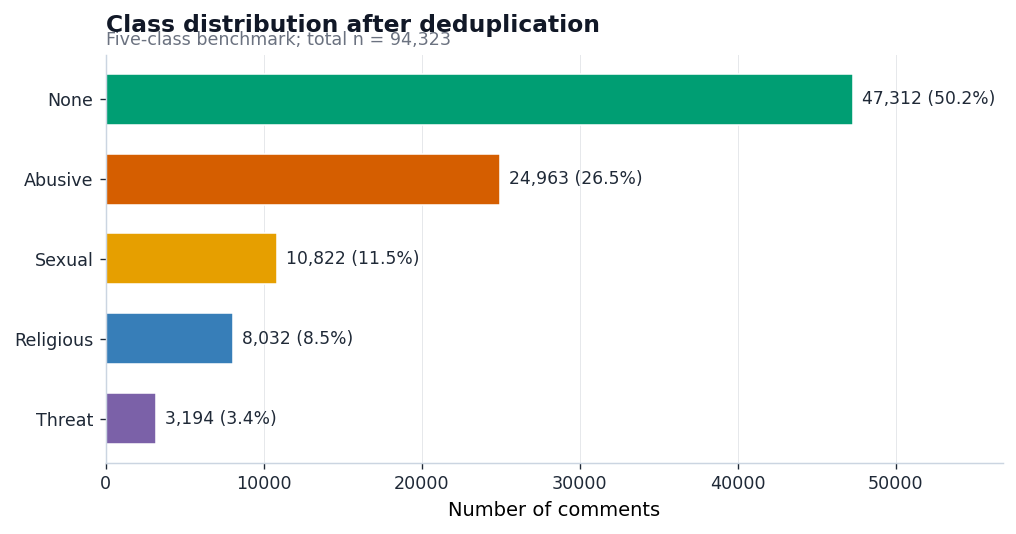

saved: outputs/paper_q1/figures/fig01_class_distribution.png


In [162]:

# ============================================================
# 5) Figure 01 — Class distribution
# ============================================================
plot_df = CLASS_DISTRIBUTION.sort_values("Samples", ascending=True).copy()
fig, ax = plt.subplots(figsize=(7.4, 3.9))
colors = [CLASS_COL[c] for c in plot_df["Class"]]
ax.barh(plot_df["Class"].map(pretty_class), plot_df["Samples"], color=colors, edgecolor="white", linewidth=0.8, height=0.64)
maxv = plot_df["Samples"].max()
for i, (_, row) in enumerate(plot_df.iterrows()):
    label = f"{int(row['Samples']):,} ({row['Share (%)']:.1f}%)"
    ax.text(row["Samples"] + maxv*0.012, i, label, va="center", ha="left", fontsize=8.8, color=COL["text"])
title(ax, "Class distribution after deduplication", f"Five-class benchmark; total n = {N_TOTAL:,}")
ax.set_xlabel("Number of comments")
ax.set_ylabel("")
ax.set_xlim(0, maxv*1.20)
clean_ax(ax, "x")
savefig("fig01_class_distribution")


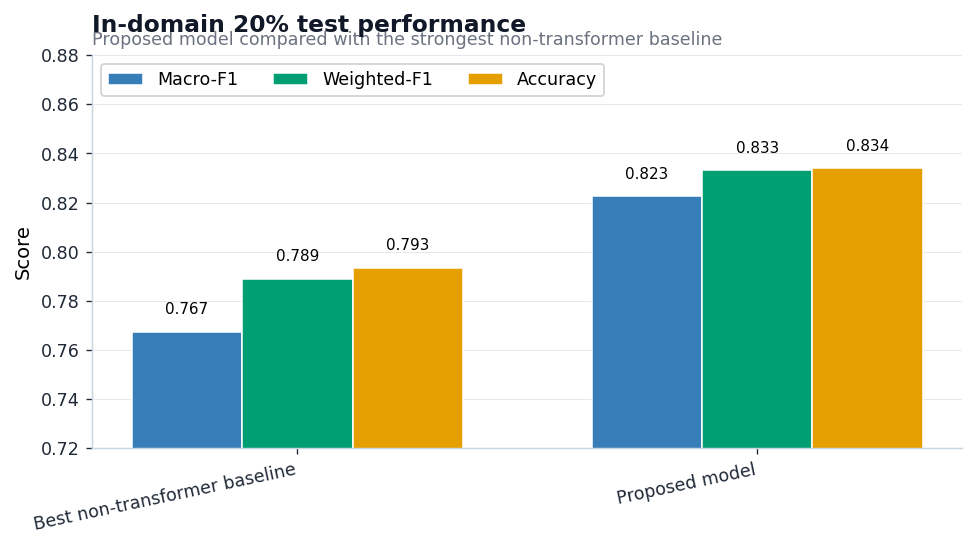

saved: outputs/paper_q1/figures/fig02_main_results.png


In [163]:

# ============================================================
# 6) Figure 02 — Main benchmark result
# ============================================================
plot_df = main_results.copy()
metrics = ["Macro-F1", "Weighted-F1", "Accuracy"]
x = np.arange(len(plot_df))
w = 0.24
fig, ax = plt.subplots(figsize=(7.1, 4.0))
metric_colors = [COL["blue"], COL["green"], COL["orange"]]
for j, m in enumerate(metrics):
    vals = plot_df[m].astype(float).values
    bars = ax.bar(x + (j-1)*w, vals, width=w, color=metric_colors[j], edgecolor="white", linewidth=0.8, label=m)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h+0.006, f"{h:.3f}", ha="center", va="bottom", fontsize=7.8, rotation=0)

title(ax, "In-domain 20% test performance", "Proposed model compared with the strongest non-transformer baseline")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["System"], rotation=12, ha="right")
ax.set_ylim(0.72, 0.88)
ax.legend(loc="upper left", ncol=3)
clean_ax(ax, "y")
savefig("fig02_main_results")


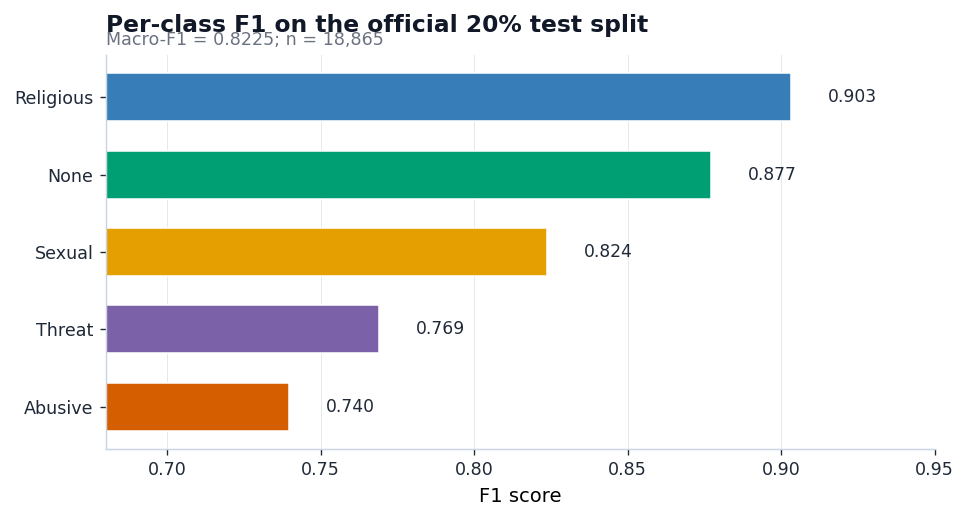

saved: outputs/paper_q1/figures/fig03_per_class_f1.png


In [164]:

# ============================================================
# 7) Figure 03 — Per-class F1 of the proposed model
# ============================================================
plot_df = report_df.sort_values("F1", ascending=True).copy()
fig, ax = plt.subplots(figsize=(7.0, 3.8))
bar_colors = [CLASS_COL[k.lower()] for k in plot_df["Class"]]
ax.barh(plot_df["Class"], plot_df["F1"], color=bar_colors, edgecolor="white", linewidth=0.8, height=0.62)
for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.F1 + 0.012, i, f"{row.F1:.3f}", va="center", ha="left", fontsize=8.8, color=COL["text"])
title(ax, "Per-class F1 on the official 20% test split", f"Macro-F1 = {proposed_metrics['macro_f1']:.4f}; n = {proposed_metrics['n_test']:,}")
ax.set_xlabel("F1 score")
ax.set_ylabel("")
ax.set_xlim(0.68, 0.95)
clean_ax(ax, "x")
savefig("fig03_per_class_f1")


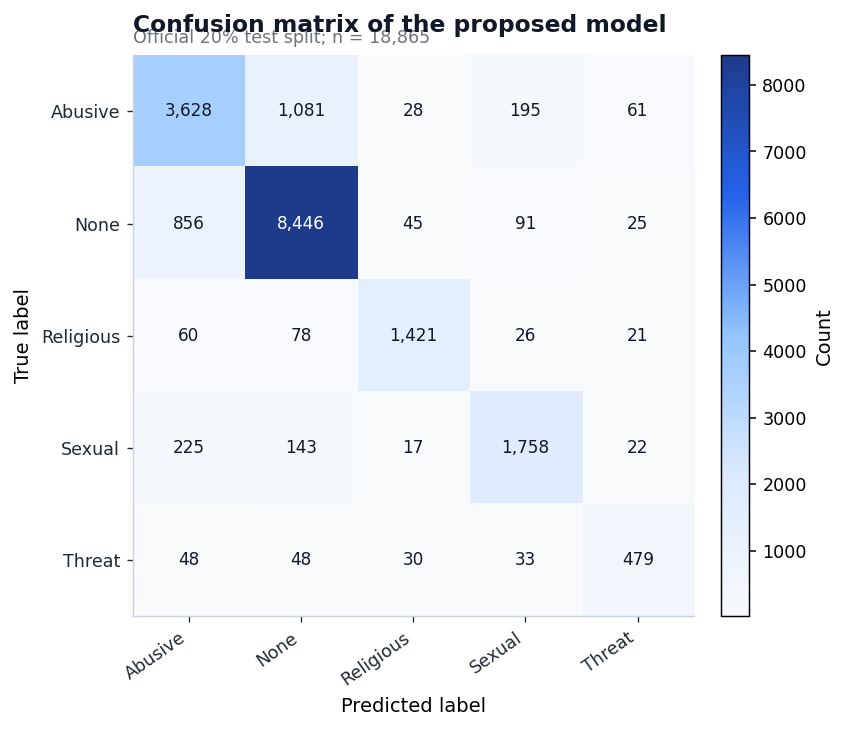

saved: outputs/paper_q1/figures/fig04_confusion_matrix.png


In [165]:

# ============================================================
# 8) Figure 04 — Confusion matrix
# ============================================================
fig, ax = plt.subplots(figsize=(6.2, 5.3))
im = ax.imshow(CM, cmap=HEAT_CMAP)
ax.set_xticks(range(len(CM_LABELS)))
ax.set_yticks(range(len(CM_LABELS)))
ax.set_xticklabels([pretty_class[x] for x in CM_LABELS], rotation=35, ha="right")
ax.set_yticklabels([pretty_class[x] for x in CM_LABELS])
for i in range(CM.shape[0]):
    for j in range(CM.shape[1]):
        val = CM[i, j]
        color = "white" if val > CM.max()*0.45 else COL["black"]
        ax.text(j, i, f"{val:,}", ha="center", va="center", fontsize=8.7, color=color)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
title(ax, "Confusion matrix of the proposed model", f"Official 20% test split; n = {CM.sum():,}")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Count", rotation=90)
clean_ax(ax, None)
savefig("fig04_confusion_matrix")


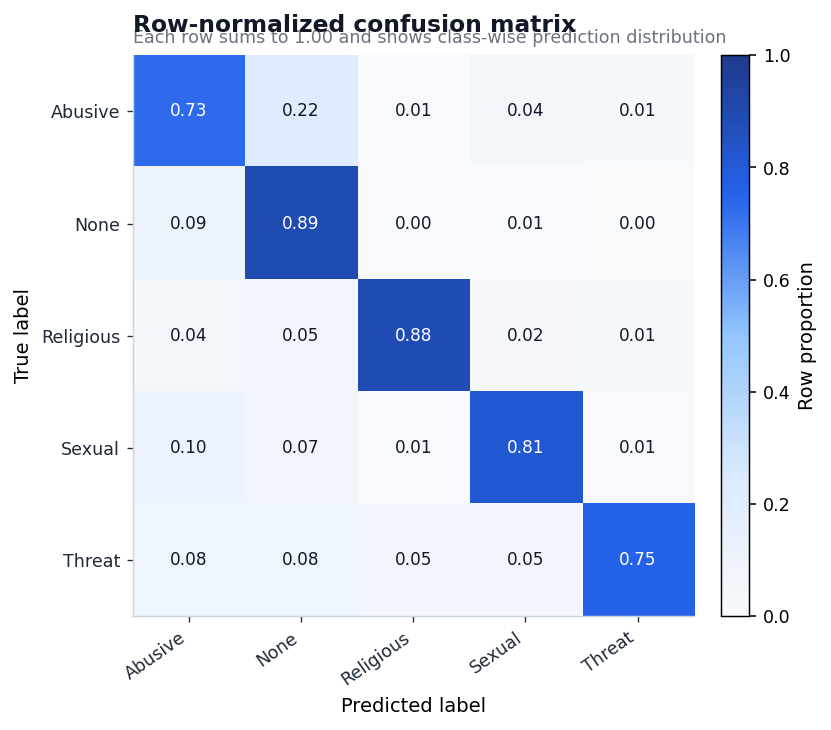

saved: outputs/paper_q1/figures/fig04b_confusion_matrix_normalized.png


In [166]:

# ============================================================
# 9) Figure 04b — Row-normalized confusion matrix
# ============================================================
CMN = CM / CM.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.2, 5.3))
im = ax.imshow(CMN, cmap=HEAT_CMAP, vmin=0, vmax=1)
ax.set_xticks(range(len(CM_LABELS)))
ax.set_yticks(range(len(CM_LABELS)))
ax.set_xticklabels([pretty_class[x] for x in CM_LABELS], rotation=35, ha="right")
ax.set_yticklabels([pretty_class[x] for x in CM_LABELS])
for i in range(CMN.shape[0]):
    for j in range(CMN.shape[1]):
        val = CMN[i, j]
        color = "white" if val > 0.45 else COL["black"]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8.7, color=color)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
title(ax, "Row-normalized confusion matrix", "Each row sums to 1.00 and shows class-wise prediction distribution")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Row proportion", rotation=90)
clean_ax(ax, None)
savefig("fig04b_confusion_matrix_normalized")


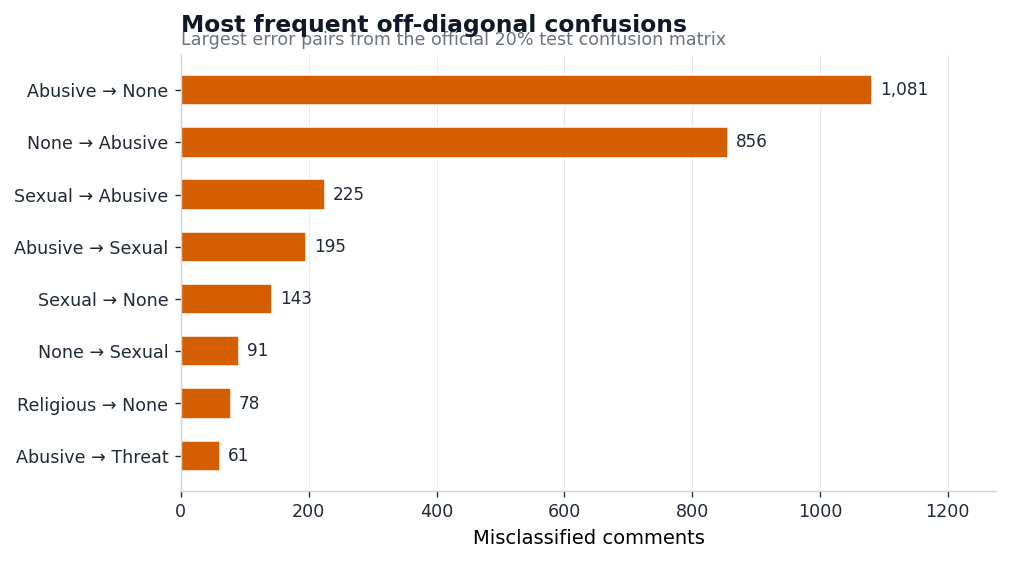

saved: outputs/paper_q1/figures/fig05_top_confusions.png


In [167]:

# ============================================================
# 10) Figure 05 — Top off-diagonal confusions
# ============================================================
confusions = []
for i, t in enumerate(CM_LABELS):
    for j, p in enumerate(CM_LABELS):
        if i != j:
            confusions.append({"True": pretty_class[t], "Predicted": pretty_class[p], "Count": int(CM[i, j])})
top = pd.DataFrame(confusions).sort_values("Count", ascending=False).head(8)
top["Pair"] = top["True"] + " → " + top["Predicted"]
plot_df = top.sort_values("Count", ascending=True)
fig, ax = plt.subplots(figsize=(7.3, 4.1))
ax.barh(plot_df["Pair"], plot_df["Count"], color=COL["vermillion"], edgecolor="white", linewidth=0.8, height=0.58)
maxv = plot_df["Count"].max()
for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.Count + maxv*0.012, i, f"{row.Count:,}", va="center", fontsize=8.7, color=COL["text"])
title(ax, "Most frequent off-diagonal confusions", "Largest error pairs from the official 20% test confusion matrix")
ax.set_xlabel("Misclassified comments")
ax.set_ylabel("")
ax.set_xlim(0, maxv*1.18)
clean_ax(ax, "x")
savefig("fig05_top_confusions")


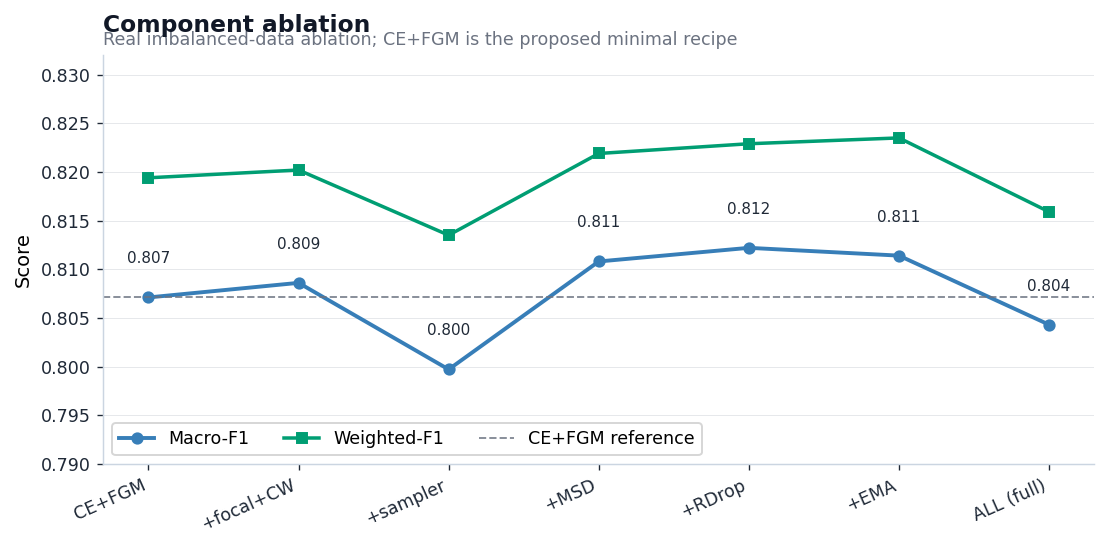

saved: outputs/paper_q1/figures/fig06_component_ablation.png


In [168]:

# ============================================================
# 11) Figure 06 — Component ablation
# ============================================================
plot_df = component_clean.copy()
fig, ax = plt.subplots(figsize=(8.0, 4.0))
x = np.arange(len(plot_df))
ax.plot(x, plot_df["Macro-F1"], color=COL["blue"], marker="o", linewidth=2.0, markersize=5.3, label="Macro-F1")
ax.plot(x, plot_df["Weighted-F1"], color=COL["green"], marker="s", linewidth=1.8, markersize=4.8, label="Weighted-F1")
base = plot_df.loc[plot_df["Configuration"].str.startswith("CE+FGM"), "Macro-F1"].iloc[0]
ax.axhline(base, color=COL["muted"], linestyle="--", linewidth=1.0, alpha=0.8, label="CE+FGM reference")
for i, (_, row) in enumerate(plot_df.iterrows()):
    label = f"{row['Macro-F1']:.3f}"
    ax.text(i, row["Macro-F1"] + 0.0032, label, ha="center", va="bottom", fontsize=7.8, color=COL["text"])
title(ax, "Component ablation", "Real imbalanced-data ablation; CE+FGM is the proposed minimal recipe")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Configuration"], rotation=24, ha="right")
ax.set_ylim(0.790, 0.832)
ax.legend(loc="lower left", ncol=3)
clean_ax(ax, "y")
savefig("fig06_component_ablation")


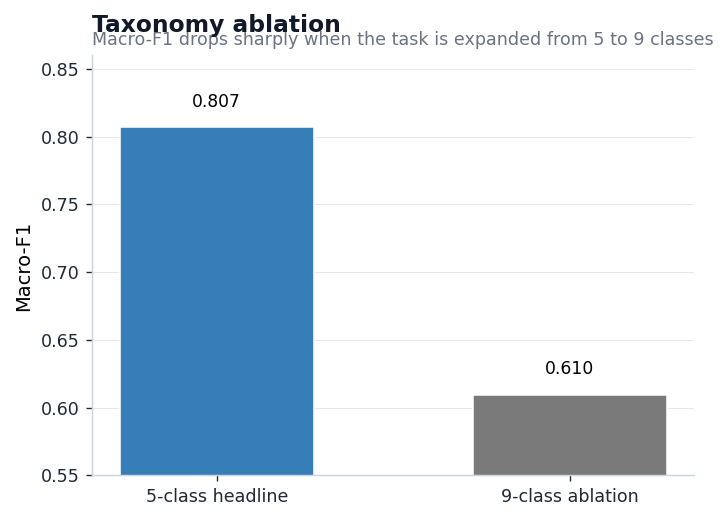

saved: outputs/paper_q1/figures/fig07_taxonomy_ablation.png


In [169]:

# ============================================================
# 12) Figure 07 — Taxonomy ablation
# ============================================================
plot_df = taxonomy_clean.copy()
plot_df["Taxonomy"] = plot_df["Taxonomy"].replace({"5-class":"5-class headline", "9-class":"9-class ablation"})
fig, ax = plt.subplots(figsize=(5.4, 3.8))
x = np.arange(len(plot_df))
colors = [COL["blue"], COL["gray"]][:len(plot_df)]
ax.bar(x, plot_df["Macro-F1"], color=colors, edgecolor="white", linewidth=0.8, width=0.55)
for i, (_, row) in enumerate(plot_df.iterrows()):
    label = f"{row['Macro-F1']:.3f}"
    ax.text(i, row["Macro-F1"] + 0.012, label, ha="center", va="bottom", fontsize=8.8)
title(ax, "Taxonomy ablation", "Macro-F1 drops sharply when the task is expanded from 5 to 9 classes")
ax.set_ylabel("Macro-F1")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Taxonomy"])
ax.set_ylim(0.55, 0.86)
clean_ax(ax, "y")
savefig("fig07_taxonomy_ablation")


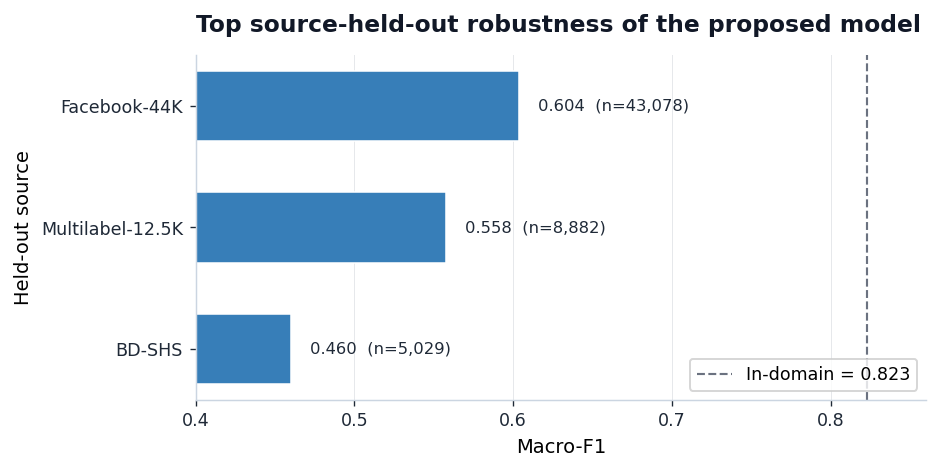

saved: outputs/paper_q1/figures/fig08_robustness.png


In [170]:
# ============================================================
# 13) Figure 08 — Top source-held-out robustness
# ============================================================
plot_df = robust_clean.copy().sort_values("Macro-F1", ascending=True)

fig, ax = plt.subplots(figsize=(6.8, 3.45))

labels = plot_df["Held-out"].astype(str)

ax.barh(
    labels,
    plot_df["Macro-F1"],
    color=COL["blue"],
    edgecolor="white",
    linewidth=0.8,
    height=0.58,
)

for i, (_, row) in enumerate(plot_df.iterrows()):
    label = f"{row['Macro-F1']:.3f}  (n={int(row['n_test']):,})"
    ax.text(
        row["Macro-F1"] + 0.012,
        i,
        label,
        va="center",
        fontsize=8.4,
        color=COL["text"],
    )

ax.axvline(
    proposed_metrics["macro_f1"],
    color=COL["muted"],
    linestyle="--",
    linewidth=1.1,
    label=f"In-domain = {proposed_metrics['macro_f1']:.3f}",
)

ax.legend(loc="lower right")

title(
    ax,
    "Top source-held-out robustness of the proposed model",
)

ax.set_xlabel("Macro-F1")
ax.set_ylabel("Held-out source")
ax.set_xlim(0.40, 0.86)

clean_ax(ax, "x")
savefig("fig08_robustness")

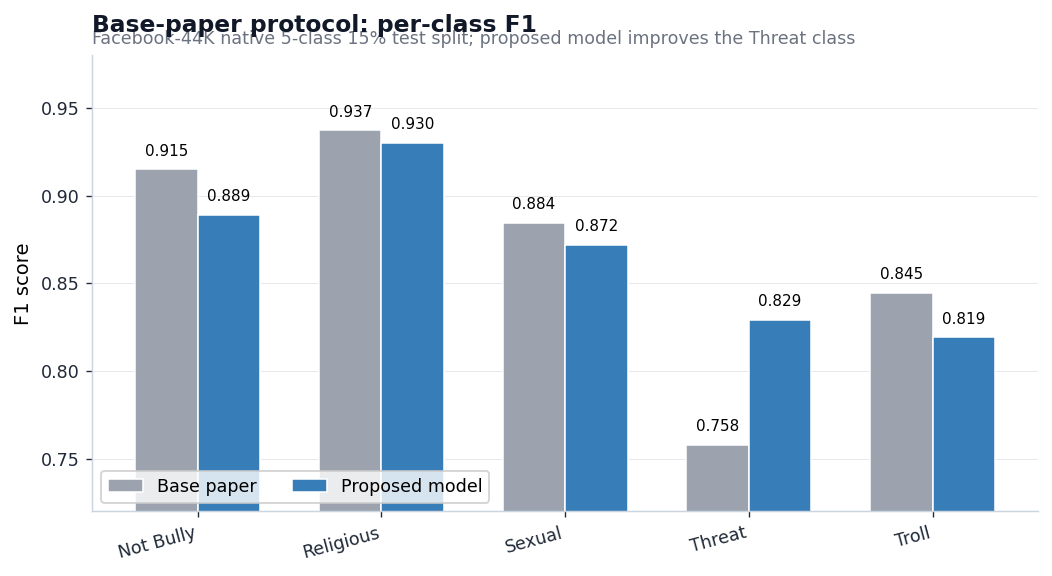

saved: outputs/paper_q1/figures/fig09_basepaper_comparison.png


In [171]:

# ============================================================
# 14) Figure 09 — Base-paper comparison, Facebook-44K protocol
# ============================================================
plot_df = basepaper_per_class.copy()
fig, ax = plt.subplots(figsize=(7.6, 4.2))
x = np.arange(len(plot_df))
w = 0.34
b1 = ax.bar(x - w/2, plot_df["Base paper"], width=w, color="#9CA3AF", edgecolor="white", linewidth=0.8, label="Base paper")
b2 = ax.bar(x + w/2, plot_df["Proposed model"], width=w, color=COL["blue"], edgecolor="white", linewidth=0.8, label="Proposed model")
for bars in [b1, b2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h+0.006, f"{h:.3f}", ha="center", va="bottom", fontsize=7.8)
title(ax, "Base-paper protocol: per-class F1", "Facebook-44K native 5-class 15% test split; proposed model improves the Threat class")
ax.set_ylabel("F1 score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Class"], rotation=15, ha="right")
ax.set_ylim(0.72, 0.98)
ax.legend(loc="lower left", ncol=2)
clean_ax(ax, "y")
savefig("fig09_basepaper_comparison")


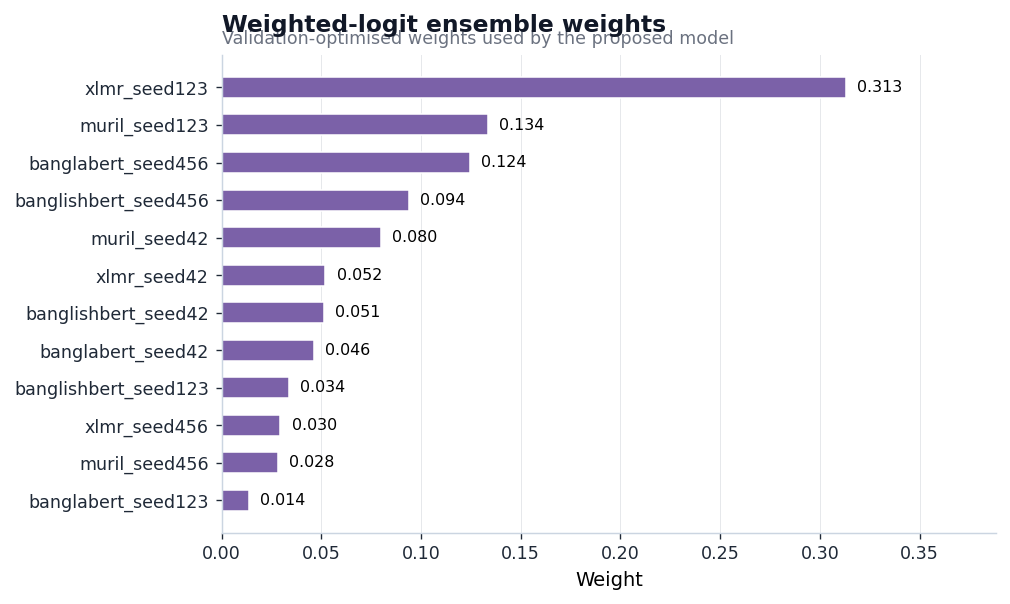

saved: outputs/paper_q1/figures/fig10_ensemble_weights.png


In [172]:

# ============================================================
# 15) Figure 10 — Ensemble weights
# ============================================================
if len(weights_df) > 0:
    plot_df = weights_df.sort_values("Weight", ascending=True).copy()
    fig, ax = plt.subplots(figsize=(7.3, 4.4))
    ax.barh(plot_df["Run"], plot_df["Weight"], color=COL["purple"], edgecolor="white", linewidth=0.8, height=0.56)
    maxv = plot_df["Weight"].max()
    for i, row in enumerate(plot_df.itertuples()):
        ax.text(row.Weight + maxv*0.018, i, f"{row.Weight:.3f}", va="center", fontsize=8.2)
    title(ax, "Weighted-logit ensemble weights", "Validation-optimised weights used by the proposed model")
    ax.set_xlabel("Weight")
    ax.set_ylabel("")
    ax.set_xlim(0, maxv*1.24)
    clean_ax(ax, "x")
    savefig("fig10_ensemble_weights")
else:
    print("No weights found; skipped figure 10.")


In [173]:

# ============================================================
# 16) Final audit — fail loudly if core values are inconsistent
# ============================================================
# Count consistency
assert CLASS_DISTRIBUTION["Samples"].sum() == N_TOTAL, "Class counts do not sum to N_TOTAL"
assert sum(RANDOM_SPLIT.values()) == N_TOTAL, "Random split sizes do not sum to N_TOTAL"
assert SOURCE_DISTRIBUTION["Samples"].sum() == N_TOTAL, "Source counts do not sum to N_TOTAL"
assert SCRIPT_DISTRIBUTION["Samples"].sum() == N_TOTAL, "Script counts do not sum to N_TOTAL"
assert CM.sum() == proposed_metrics["n_test"] == RANDOM_SPLIT["test"], "Confusion matrix/test size mismatch"

# F1 consistency with official JSON
for _, row in per_class_merged.iterrows():
    msg = f"Per-class F1 mismatch for {row['Class']}: {row['F1']} vs {row['Official F1']}"
    assert abs(row["F1"] - row["Official F1"]) < 5e-4, msg

# Source policy
for s in used_sources:
    if s["source_path"] != "embedded_authoritative_constant":
        assert not is_banned(s["source_path"]), f"Banned source used: {s['source_path']}"

# Main metric consistency
assert abs(report_plus.loc[report_plus["Class"] == "Macro average", "F1"].iloc[0] - proposed_metrics["macro_f1"]) < 5e-4
assert abs(report_plus.loc[report_plus["Class"] == "Weighted average", "F1"].iloc[0] - proposed_metrics["weighted_f1"]) < 5e-4
assert abs(np.trace(CM) / CM.sum() - proposed_metrics["accuracy"]) < 5e-4

print("✅ Audit passed")
print(f"Generated figures: {FIG}")
print(f"Generated tables : {TAB}")
print("No altmethod/precheck files were read.")


✅ Audit passed
Generated figures: /Users/sefayet/Desktop/Github/CyberBully_Detection_Paper/outputs/paper_q1/figures
Generated tables : /Users/sefayet/Desktop/Github/CyberBully_Detection_Paper/outputs/paper_q1/tables
No altmethod/precheck files were read.


saved table: outputs/paper_q1/tables/table_dataset_source_composition.csv
saved table: outputs/paper_q1/tables/table_dataset_script_composition.csv
saved table: outputs/paper_q1/tables/table_dataset_class_composition.csv


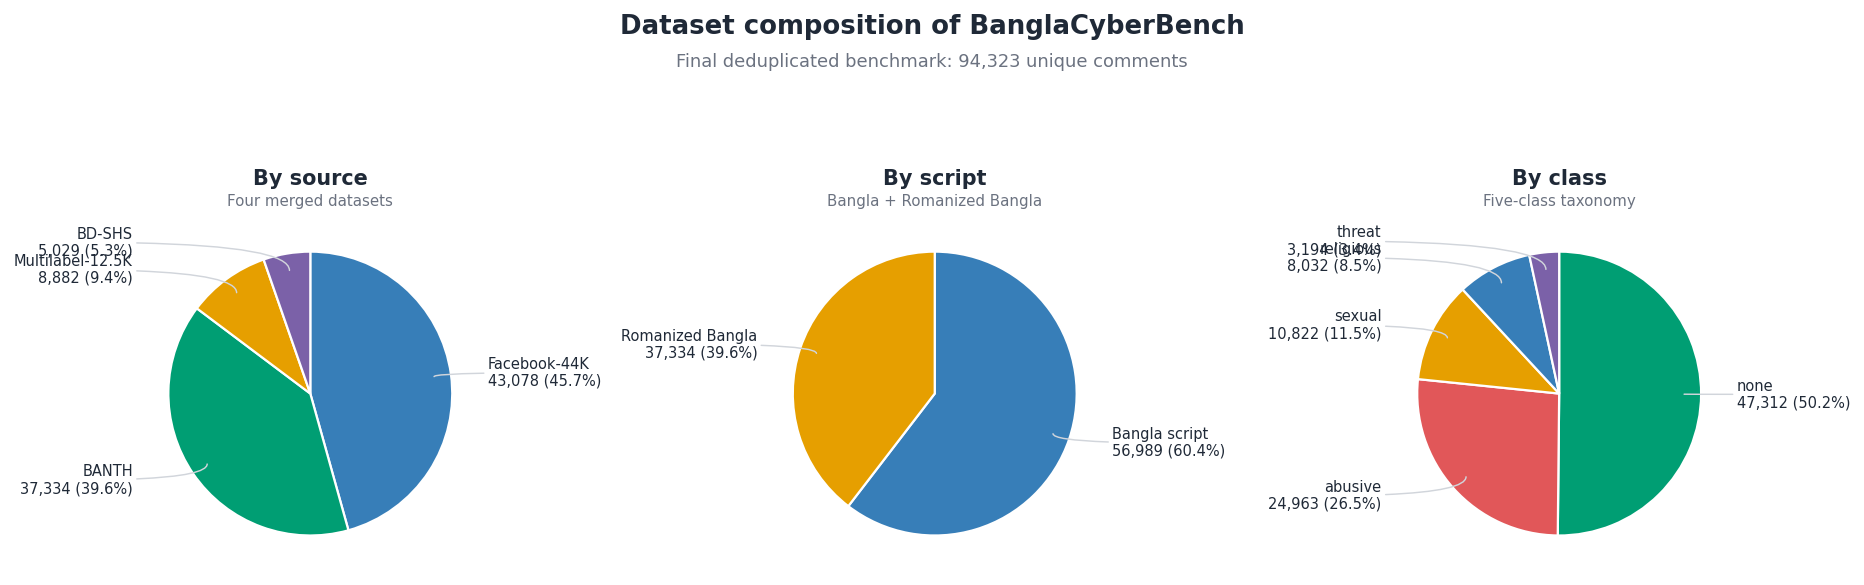

saved: outputs/paper_q1/figures/fig_dataset_composition_pies.png


In [175]:
# ============================================================
# Figure — Dataset composition overview with professional pie charts
# ============================================================

# -----------------------------
# Data: final deduplicated benchmark
# -----------------------------
source_pie = pd.DataFrame({
    "Group": ["Facebook-44K", "BANTH", "Multilabel-12.5K", "BD-SHS"],
    "Samples": [43078, 37334, 8882, 5029],
})

script_pie = pd.DataFrame({
    "Group": ["Bangla script", "Romanized Bangla"],
    "Samples": [56989, 37334],
})

class_pie = pd.DataFrame({
    "Group": ["none", "abusive", "sexual", "religious", "threat"],
    "Samples": [47312, 24963, 10822, 8032, 3194],
})

for df in [source_pie, script_pie, class_pie]:
    df["Share (%)"] = df["Samples"] / df["Samples"].sum() * 100

# -----------------------------
# Save composition tables
# -----------------------------
save_table(
    source_pie.copy(),
    "table_dataset_source_composition",
    "Source-wise composition of the deduplicated BanglaCyberBench benchmark.",
    "tab:dataset_source_composition"
)

save_table(
    script_pie.copy(),
    "table_dataset_script_composition",
    "Script-wise composition of the deduplicated BanglaCyberBench benchmark.",
    "tab:dataset_script_composition"
)

save_table(
    class_pie.copy(),
    "table_dataset_class_composition",
    "Class-wise composition of the deduplicated BanglaCyberBench benchmark.",
    "tab:dataset_class_composition"
)

# -----------------------------
# Safe color palette
# Does not depend on CLASS_COLORS
# -----------------------------
blue = COL.get("blue", "#4C78A8")
orange = COL.get("orange", "#F28E2B")
green = COL.get("green", "#59A14F")
purple = COL.get("purple", "#B07AA1")
red = COL.get("red", "#E15759")
gray = COL.get("muted", "#6B7280")
text_col = COL.get("text", "#111827")
grid_col = COL.get("grid", "#D1D5DB")

source_colors = [
    blue,      # Facebook-44K
    green,     # BANTH
    orange,    # Multilabel-12.5K
    purple,    # BD-SHS
]

script_colors = [
    blue,      # Bangla script
    orange,    # Romanized Bangla
]

class_colors = [
    green,     # none
    red,       # abusive
    orange,    # sexual
    blue,      # religious
    purple,    # threat
]

# -----------------------------
# Helper for clean pie charts
# -----------------------------
def draw_professional_pie(ax, df, colors, chart_title, chart_subtitle=None):
    df = df.sort_values("Samples", ascending=False).reset_index(drop=True)

    wedges, _ = ax.pie(
        df["Samples"],
        colors=colors[:len(df)],
        startangle=90,
        counterclock=False,
        labels=None,
        normalize=True,
        wedgeprops={
            "edgecolor": "white",
            "linewidth": 1.15,
        },
    )

    for i, wedge in enumerate(wedges):
        row = df.iloc[i]

        angle = (wedge.theta1 + wedge.theta2) / 2.0
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        label = "{}\n{:,} ({:.1f}%)".format(
            row["Group"],
            int(row["Samples"]),
            row["Share (%)"],
        )

        ax.annotate(
            label,
            xy=(0.88 * x, 0.88 * y),
            xytext=(1.25 * np.sign(x), 1.08 * y),
            ha="left" if x >= 0 else "right",
            va="center",
            fontsize=7.5,
            color=text_col,
            linespacing=1.15,
            arrowprops={
                "arrowstyle": "-",
                "color": grid_col,
                "lw": 0.75,
                "shrinkA": 0,
                "shrinkB": 0,
                "connectionstyle": "angle3,angleA=0,angleB=90",
            },
        )

    ax.set_title(
        chart_title,
        fontsize=10.7,
        fontweight="bold",
        color=text_col,
        pad=16,
    )

    if chart_subtitle is not None:
        ax.text(
            0.5,
            1.02,
            chart_subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=7.7,
            color=gray,
        )

    ax.set_aspect("equal")
    ax.set_axis_off()


# -----------------------------
# Plot: 3 professional pie charts
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.55))

draw_professional_pie(
    axes[0],
    source_pie,
    source_colors,
    "By source",
    "Four merged datasets",
)

draw_professional_pie(
    axes[1],
    script_pie,
    script_colors,
    "By script",
    "Bangla + Romanized Bangla",
)

draw_professional_pie(
    axes[2],
    class_pie,
    class_colors,
    "By class",
    "Five-class taxonomy",
)

fig.suptitle(
    "Dataset composition of BanglaCyberBench",
    fontsize=13.4,
    fontweight="bold",
    color=text_col,
    y=1.06,
)

fig.text(
    0.5,
    0.985,
    "Final deduplicated benchmark: 94,323 unique comments",
    ha="center",
    va="center",
    fontsize=9.2,
    color=gray,
)

plt.subplots_adjust(wspace=0.58)

savefig("fig_dataset_composition_pies")